<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/C%C3%B3pia_de_TAREFA1_PR%C3%81TICA_BLOCO3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import os # Para verificar a existência de arquivos
from google.colab import drive # Para fazer upload de arquivos
drive.mount('/content/drive')





Mounted at /content/drive


In [ ]:
df_treino = pd.read_csv('/content/drive/MyDrive/RNA_Datasets/bebidas.csv')
df_teste = pd.read_csv('/content/drive/MyDrive/RNA_Datasets/bebidasTestes.csv')
print(df_treino)
print(df_teste)

         x1      x2      x3      x4  d1  d2  d3
0    0.3841  0.2021  0.0000  0.2438   1   0   0
1    0.1765  0.1613  0.3401  0.0843   1   0   0
2    0.3170  0.5786  0.3387  0.4192   0   1   0
3    0.2467  0.0337  0.2699  0.3454   1   0   0
4    0.6102  0.8192  0.4679  0.4762   0   1   0
..      ...     ...     ...     ...  ..  ..  ..
125  0.4155  0.6589  0.5310  0.5404   0   1   0
126  0.3934  0.6244  0.4817  0.4324   0   1   0
127  0.5843  0.8517  0.8576  0.7133   0   0   1
128  0.1995  0.3690  0.3537  0.3462   1   0   0
129  0.3832  0.2321  0.0341  0.2450   1   0   0

[130 rows x 7 columns]
        x1      x2      x3      x4  d1  d2  d3
0   0.8622  0.7101  0.6236  0.7894   0   0   1
1   0.2741  0.1552  0.1333  0.1516   1   0   0
2   0.6772  0.8516  0.6543  0.7573   0   0   1
3   0.2178  0.5039  0.6415  0.5039   0   1   0
4   0.7260  0.7500  0.7007  0.4953   0   0   1
5   0.2473  0.2941  0.4248  0.3087   1   0   0
6   0.5682  0.5683  0.5054  0.4426   0   1   0
7   0.6566  0.6715  0.49

In [ ]:
# Separar features (X) e targets (y) para o conjunto de treino
X_treino = df_treino[['x1', 'x2', 'x3', 'x4']]

# Converter one-hot encoding (d1, d2, d3) para uma única coluna de classe
# Mapeamento: 0=Tipo A (d1), 1=Tipo B (d2), 2=Tipo C (d3)
y_treino = df_treino[['d1', 'd2', 'd3']].to_numpy().argmax(axis=1)

print(f"Shape de X_treino: {X_treino.shape}")
print(f"Shape de y_treino: {y_treino.shape}")
print(f"Primeiras 5 amostras de y_treino: {y_treino[:5]}")

# Separar features (X) e targets (y) para o conjunto de teste
X_teste = df_teste[['x1', 'x2', 'x3', 'x4']]
y_teste = df_teste[['d1', 'd2', 'd3']].to_numpy().argmax(axis=1)

print(f"Shape de X_teste: {X_teste.shape}")
print(f"Shape de y_teste: {y_teste.shape}")
print(f"Primeiras 5 amostras de y_teste: {y_teste[:5]}")




Shape de X_treino: (130, 4)
Shape de y_treino: (130,)
Primeiras 5 amostras de y_treino: [0 0 1 0 1]
Shape de X_teste: (18, 4)
Shape de y_teste: (18,)
Primeiras 5 amostras de y_teste: [2 0 2 1 2]


In [ ]:
# 3. Item 1: Treinamento de 3 MLPs com Diferentes Neurônios ---

neuronios_ocultos = [5, 10, 15]
mlps = {}
loss_curves = {}
final_losses = {}

# Parâmetros fixos para todos os MLPs
mlp_params = {
    'activation': 'logistic',
    'learning_rate_init': 0.001,
    'learning_rate': 'constant',
    'tol': 1e-6, # Epsilon no contexto de tolerância para otimização<br/>
    'max_iter': 5000,
    'random_state': 42,
    'verbose': False # Desativa a saída detalhada do treinamento para não poluir o console
}



In [ ]:
for n_neurons in neuronios_ocultos:
    print(f"Treinando MLP com {n_neurons} neurônios na camada oculta...")
    mlp = MLPClassifier(hidden_layer_sizes=(n_neurons,), **mlp_params)
    mlp.fit(X_treino, y_treino)

    mlps[n_neurons] = mlp
    loss_curves[n_neurons] = mlp.loss_curve_
    final_losses[n_neurons] = mlp.loss_

    print(f"MLP com {n_neurons} neurônios treinado. Perda final: {mlp.loss_:.6f}")


Treinando MLP com 5 neurônios na camada oculta...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP com 5 neurônios treinado. Perda final: 0.104767
Treinando MLP com 10 neurônios na camada oculta...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP com 10 neurônios treinado. Perda final: 0.090959
Treinando MLP com 15 neurônios na camada oculta...
MLP com 15 neurônios treinado. Perda final: 0.084603


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


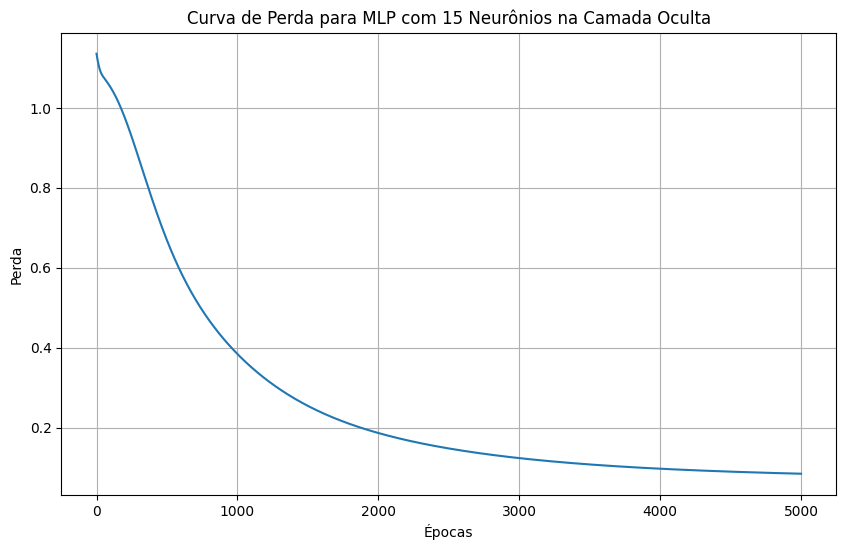

Gráfico da curva de perda salvo como 'loss_curve_15_neurons.png'


In [ ]:
# Plotar e salvar a curva de perda

plt.figure(figsize=(10, 6))
plt.plot(loss_curves[n_neurons])
plt.title(f"Curva de Perda para MLP com {n_neurons} Neurônios na Camada Oculta")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.grid(True)
filename = f"loss_curve_{n_neurons}_neurons.png"
plt.savefig(filename)
plt.show()
print(f"Gráfico da curva de perda salvo como '{filename}'")





In [ ]:
# Tabela de resultados para o relatório
print("--- Tabela de Perdas Finais ---")
for n_neurons in neuronios_ocultos:

# Identificar a melhor configuração com base na menor perda
  best_n_neurons = min(final_losses, key=final_losses.get)
  best_mlp = mlps[best_n_neurons]
  print(f"Melhor configuração (menor perda): MLP com {best_n_neurons} neurônios (Perda: {final_losses[best_n_neurons]:.6f})")


--- Tabela de Perdas Finais ---
Melhor configuração (menor perda): MLP com 15 neurônios (Perda: 0.084603)
Melhor configuração (menor perda): MLP com 15 neurônios (Perda: 0.084603)
Melhor configuração (menor perda): MLP com 15 neurônios (Perda: 0.084603)


Utilizando o melhor modelo (MLP com 15 neurônios) para avaliação no conjunto de teste.
Acurácia no conjunto de teste: 100.00%
Matriz de Confusão:
[[6 0 0]
 [0 5 0]
 [0 0 7]]


<Figure size 800x600 with 0 Axes>

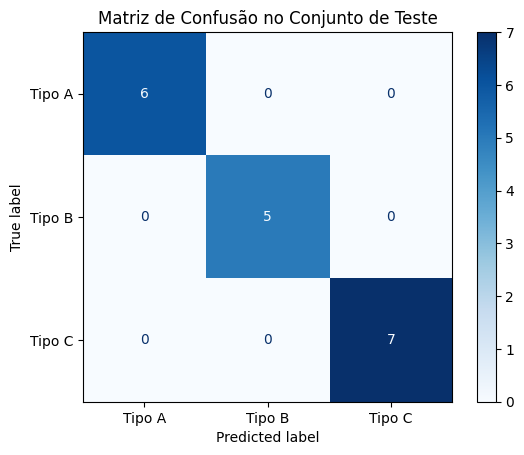

Gráfico da matriz de confusão salvo como 'confusion_matrix.png'
Relatório de Classificação:
              precision    recall  f1-score   support

      Tipo A       1.00      1.00      1.00         6
      Tipo B       1.00      1.00      1.00         5
      Tipo C       1.00      1.00      1.00         7

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

 Fim da Execução 
Por favor, use os resultados acima e os gráficos salvos para preencher o relatório.


In [ ]:
# 4. Validação com o Conjunto de Teste ---
print(f"Utilizando o melhor modelo (MLP com {best_n_neurons} neurônios) para avaliação no conjunto de teste.")

# Fazer previsões no conjunto de teste
y_pred = best_mlp.predict(X_teste)

# Calcular e apresentar a acurácia
accuracy = accuracy_score(y_teste, y_pred) * 100
print(f"Acurácia no conjunto de teste: {accuracy:.2f}%")

# Mostrar matriz de confusão
cm = confusion_matrix(y_teste, y_pred)
print("Matriz de Confusão:")
print(cm)

# Plotar e salvar a matriz de confusão
plt.figure(figsize=(8, 6))

# Definir os nomes das classes para o display da matriz de confusão
class_names = ['Tipo A', 'Tipo B', 'Tipo C']
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cm_display.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão no Conjunto de Teste")
filename_cm = "confusion_matrix.png"
plt.savefig(filename_cm)
plt.show()
print(f"Gráfico da matriz de confusão salvo como '{filename_cm}'")

# Mostrar relatório de classificação
print("Relatório de Classificação:")

# target_names deve corresponder ao mapeamento 0=Tipo A, 1=Tipo B, 2=Tipo C
report = classification_report(y_teste, y_pred, target_names=class_names)
print(report)

print(" Fim da Execução ")
print("Por favor, use os resultados acima e os gráficos salvos para preencher o relatório.")

